#  Step 1: Install TensorFlow.js for Python

In [5]:
!pip install tensorflowjs tensorflow numpy pillow opencv-python


  Using cached tensorflowjs-4.22.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached tensorflow_decision_forests-1.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.3 kB)
  Using cached tf_keras-2.19.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflowjs-4.22.0-py3-none-any.whl (89 kB)
Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (644.9 MB)
Using cached tensorflow_decision_forests-1.12.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.1 MB)
Using cached tf_keras-2.19.0-py3-none-any.whl (1.7 MB)
  Attempting uninstall: tf-keras
    Found existing installation: tf_keras 2.18.0
    Uninstalling tf_keras-2.18.0:
      Successfully uninstalled tf_keras-2.18.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sour

# Step 2: Upload Teachable Machine Model Files to Colab

In [2]:
from google.colab import files

# Upload model.json, metadata.json, and weights.bin
uploaded = files.upload()


Saving metadata.json to metadata (1).json
Saving model.json to model (1).json
Saving weights.bin to weights (1).bin


# Step 3: Verify Uploaded Files

In [3]:


import os

print("📂 Uploaded Files:", os.listdir())


📂 Uploaded Files: ['.config', 'metadata.json', 'model.json', 'metadata (1).json', 'model (1).json', 'weights (1).bin', 'weights.bin', 'sample_data']


# Step 4: Load Teachable Machine Model in TensorFlow.js

In [6]:
import tensorflowjs as tfjs
import tensorflow as tf
import numpy as np
import json

# Load the model.json file
with open("model.json", "r") as f:
    model_config = json.load(f)

# Load the TensorFlow.js model directly
model = tfjs.converters.load_keras_model("model.json")

print("✅ Model Loaded Successfully!")

✅ Model Loaded Successfully!


# Step 5: Upload an Image for Classification

In [7]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving diamondtest2.jpeg to diamondtest2.jpeg


🖼️ Uploaded Image:


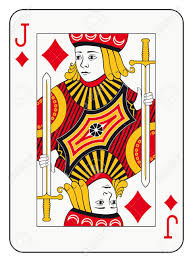

In [10]:
from IPython.display import display, Image as ColabImage

# Display uploaded image
print("🖼️ Uploaded Image:")
display(ColabImage(filename=image_path))


In [8]:
import json

# Load the metadata.json file
with open("metadata.json", "r") as f:
    metadata = json.load(f)

# Extract class labels
class_labels = metadata["labels"]
print("✅ Correct Class Names:", class_labels)

✅ Correct Class Names: ['Hearts Suit Playing Cards', 'Spades Suit Playing Cards', 'Diamond Suit Playing Cards']


 # Step 6: Preprocess and Predict Image

In [9]:
import cv2
import numpy as np

# Function to preprocess image
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))  # Resize to model input size
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    image = image / 255.0  # Normalize pixel values
    return image

# Function to make predictions with correct class names
def predict_image(image_path):
    image = preprocess_image(image_path)
    prediction = model.predict(image)  # Make prediction
    predicted_class = np.argmax(prediction)  # Get highest confidence class

    return f"Prediction: {class_labels[predicted_class]} (Confidence: {np.max(prediction):.2f})"

# Run prediction
print(predict_image(image_path))

1/1 [==============================] - 3s 3s/step
Prediction: Diamond Suit Playing Cards (Confidence: 1.00)
